# Predição de Doenças Cardiovasculares com Machine Learning

## Fundamentos de Machine Learning com Scikit-Learn - Projeto 26E1_2

---

**Objetivo:** Desenvolver modelos de Machine Learning para prever a presença de doenças cardiovasculares com base em características clínicas e demográficas dos pacientes.

**Dataset:** cardio_train.csv (70.000 registros de pacientes)

**Autor:** Anderson Corrêa

**Data:** Março, 2026

## Imports e Configurações

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import Perceptron
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

print("Imports realizados com sucesso!")

Imports realizados com sucesso!


---

# 1. Descrição do Problema e Dados

## 1.1 O Problema das Doenças Cardiovasculares

As **doenças cardiovasculares (DCV)** são a principal causa de morte no mundo, responsáveis por aproximadamente 17.9 milhões de mortes por ano segundo a OMS. Estas incluem:

- Doença arterial coronariana
- Insuficiência cardíaca
- Acidente vascular cerebral (AVC)
- Hipertensão

## 1.2 Por que Machine Learning?

A predição de DCV é um problema complexo porque:

1. **Relações não-lineares:** A interação entre fatores de risco (pressão arterial, colesterol, IMC) não segue padrões lineares simples
2. **Múltiplos fatores:** A combinação de hábitos de vida, características biológicas e histórico médico requer análise multivariada
3. **Detecção precoce:** Modelos podem identificar padrões sutis que indicam risco antes dos sintomas clínicos

## 1.3 Desafios do Domínio

- **Qualidade dos dados:** Erros de medição em pressão arterial, autorrelato impreciso de hábitos
- **Balanceamento de classes:** Necessidade de garantir representatividade adequada
- **Interpretabilidade:** Decisões médicas exigem modelos explicáveis
- **Custo de erros:** Falsos negativos podem ter consequências graves para a saúde

## 1.4 Carregamento dos Dados

In [2]:
# Load the dataset (semicolon-delimited)
df = pd.read_csv('cardio_train.csv', sep=';')

print(f"Dataset carregado com sucesso!")
print(f"Dimensões: {df.shape[0]:,} registros x {df.shape[1]} colunas")

Dataset carregado com sucesso!
Dimensões: 70,000 registros x 13 colunas


In [3]:
# Preview the first rows
df.head(10)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
5,8,21914,1,151,67.0,120,80,2,2,0,0,0,0
6,9,22113,1,157,93.0,130,80,3,1,0,0,1,0
7,12,22584,2,178,95.0,130,90,3,3,0,0,1,1
8,13,17668,1,158,71.0,110,70,1,1,0,0,1,0
9,14,19834,1,164,68.0,110,60,1,1,0,0,0,0


## 1.5 Descrição das Features

| Feature | Tipo | Descrição | Valores |
|---------|------|-----------|--------|
| **id** | Identificador | ID do paciente | Inteiro único |
| **age** | Numérico | Idade em DIAS | ~30-65 anos |
| **gender** | Categórico | Gênero | 1=Feminino, 2=Masculino |
| **height** | Numérico | Altura em cm | 55-250 cm |
| **weight** | Numérico | Peso em kg | 10-200 kg |
| **ap_hi** | Numérico | Pressão sistólica | mm Hg |
| **ap_lo** | Numérico | Pressão diastólica | mm Hg |
| **cholesterol** | Categórico | Nível de colesterol | 1=Normal, 2=Acima, 3=Muito acima |
| **gluc** | Categórico | Nível de glicose | 1=Normal, 2=Acima, 3=Muito acima |
| **smoke** | Binário | Fumante | 0=Não, 1=Sim |
| **alco** | Binário | Consumo de álcool | 0=Não, 1=Sim |
| **active** | Binário | Atividade física | 0=Inativo, 1=Ativo |
| **cardio** | Binário (Target) | Doença cardiovascular | 0=Ausente, 1=Presente |

In [4]:
# Data types and info
print("Informações do Dataset:")
print("=" * 50)
df.info()

Informações do Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [5]:
# Statistical summary
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


## 1.6 Limpeza Inicial dos Dados

Antes da análise exploratória, precisamos remover valores claramente impossíveis que indicam erros de medição ou entrada de dados.

In [6]:
# Check for missing values
print("Valores ausentes por coluna:")
print(df.isnull().sum())
print(f"\nTotal de valores ausentes: {df.isnull().sum().sum()}")

Valores ausentes por coluna:
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

Total de valores ausentes: 0


In [7]:
# Check for impossible blood pressure values
print("Análise de valores de pressão arterial:")
print("=" * 50)
print(f"ap_hi (sistólica): min={df['ap_hi'].min()}, max={df['ap_hi'].max()}")
print(f"ap_lo (diastólica): min={df['ap_lo'].min()}, max={df['ap_lo'].max()}")

# Count problematic records
negative_bp = df[(df['ap_hi'] <= 0) | (df['ap_lo'] <= 0)].shape[0]
extreme_high = df[(df['ap_hi'] > 300) | (df['ap_lo'] > 200)].shape[0]
inverted_bp = df[df['ap_lo'] >= df['ap_hi']].shape[0]

print(f"\nRegistros com pressão negativa ou zero: {negative_bp}")
print(f"Registros com pressão extremamente alta: {extreme_high}")
print(f"Registros com diastólica >= sistólica: {inverted_bp}")

Análise de valores de pressão arterial:
ap_hi (sistólica): min=-150, max=16020
ap_lo (diastólica): min=-70, max=11000

Registros com pressão negativa ou zero: 29
Registros com pressão extremamente alta: 993
Registros com diastólica >= sistólica: 1236


In [8]:
# Create a copy for cleaning
df_clean = df.copy()
initial_size = len(df_clean)

# Remove impossible blood pressure values
df_clean = df_clean[(df_clean['ap_hi'] > 0) & (df_clean['ap_hi'] < 300)]
df_clean = df_clean[(df_clean['ap_lo'] > 0) & (df_clean['ap_lo'] < 200)]
df_clean = df_clean[df_clean['ap_lo'] < df_clean['ap_hi']]

# Remove extreme height/weight outliers
df_clean = df_clean[(df_clean['height'] > 100) & (df_clean['height'] < 220)]
df_clean = df_clean[(df_clean['weight'] > 30) & (df_clean['weight'] < 200)]

final_size = len(df_clean)
removed = initial_size - final_size

print(f"Registros originais: {initial_size:,}")
print(f"Registros removidos: {removed:,} ({removed/initial_size*100:.2f}%)")
print(f"Registros restantes: {final_size:,}")

Registros originais: 70,000
Registros removidos: 1,333 (1.90%)
Registros restantes: 68,667


In [9]:
# Verify cleaning results
print("Após limpeza:")
print(f"ap_hi: min={df_clean['ap_hi'].min()}, max={df_clean['ap_hi'].max()}")
print(f"ap_lo: min={df_clean['ap_lo'].min()}, max={df_clean['ap_lo'].max()}")
print(f"height: min={df_clean['height'].min()}, max={df_clean['height'].max()}")
print(f"weight: min={df_clean['weight'].min()}, max={df_clean['weight'].max()}")

Após limpeza:
ap_hi: min=16, max=240
ap_lo: min=1, max=182
height: min=104, max=207
weight: min=31.0, max=183.0


---

# 2. Análise Exploratória de Dados (EDA)

## 2.1 Visão Geral dos Dados Limpos

In [10]:
# Overview of cleaned data
print(f"Shape: {df_clean.shape}")
print(f"\nTipos de dados:")
print(df_clean.dtypes)

Shape: (68667, 13)

Tipos de dados:
id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object


## 2.2 Conversão de Idade e Cálculo do IMC

In [11]:
# Convert age from days to years
df_clean['age_years'] = df_clean['age'] / 365

print("Idade convertida para anos:")
print(f"Min: {df_clean['age_years'].min():.1f} anos")
print(f"Max: {df_clean['age_years'].max():.1f} anos")
print(f"Média: {df_clean['age_years'].mean():.1f} anos")
print(f"Mediana: {df_clean['age_years'].median():.1f} anos")

Idade convertida para anos:
Min: 29.6 anos
Max: 65.0 anos
Média: 53.3 anos
Mediana: 54.0 anos


In [12]:
# Calculate BMI (Body Mass Index)
df_clean['bmi'] = df_clean['weight'] / ((df_clean['height'] / 100) ** 2)

print("IMC (Body Mass Index):")
print(f"Min: {df_clean['bmi'].min():.1f}")
print(f"Max: {df_clean['bmi'].max():.1f}")
print(f"Média: {df_clean['bmi'].mean():.1f}")
print(f"Mediana: {df_clean['bmi'].median():.1f}")

# BMI categories
print("\nDistribuição por categoria de IMC:")
conditions = [
    (df_clean['bmi'] < 18.5),
    (df_clean['bmi'] >= 18.5) & (df_clean['bmi'] < 25),
    (df_clean['bmi'] >= 25) & (df_clean['bmi'] < 30),
    (df_clean['bmi'] >= 30)
]
categories = ['Abaixo do peso', 'Normal', 'Sobrepeso', 'Obeso']
df_clean['bmi_category'] = np.select(conditions, categories, default='Outro')
print(df_clean['bmi_category'].value_counts())

IMC (Body Mass Index):
Min: 10.7
Max: 152.6
Média: 27.5
Mediana: 26.3

Distribuição por categoria de IMC:
bmi_category
Normal            25441
Sobrepeso         24636
Obeso             17956
Abaixo do peso      634
Name: count, dtype: int64


## 2.3 Distribuição da Variável Alvo

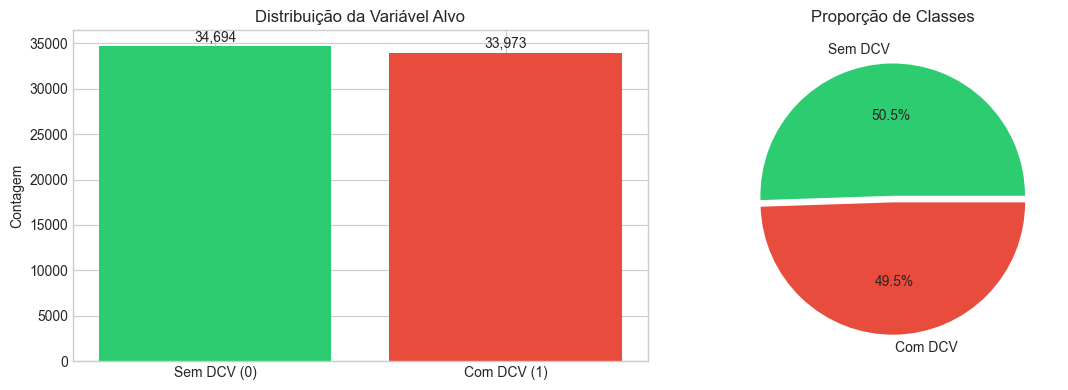


Balanceamento das classes:
Classe 0 (Sem DCV): 34,694 (50.5%)
Classe 1 (Com DCV): 33,973 (49.5%)


In [13]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
target_counts = df_clean['cardio'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Sem DCV (0)', 'Com DCV (1)'], target_counts.values, color=colors)
axes[0].set_title('Distribuição da Variável Alvo', fontsize=12)
axes[0].set_ylabel('Contagem')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=10)

# Pie chart
axes[1].pie(target_counts.values, labels=['Sem DCV', 'Com DCV'], autopct='%1.1f%%',
            colors=colors, explode=[0, 0.05])
axes[1].set_title('Proporção de Classes', fontsize=12)

plt.tight_layout()
plt.show()

print(f"\nBalanceamento das classes:")
print(f"Classe 0 (Sem DCV): {target_counts[0]:,} ({target_counts[0]/len(df_clean)*100:.1f}%)")
print(f"Classe 1 (Com DCV): {target_counts[1]:,} ({target_counts[1]/len(df_clean)*100:.1f}%)")

## 2.4 Distribuições das Features Numéricas

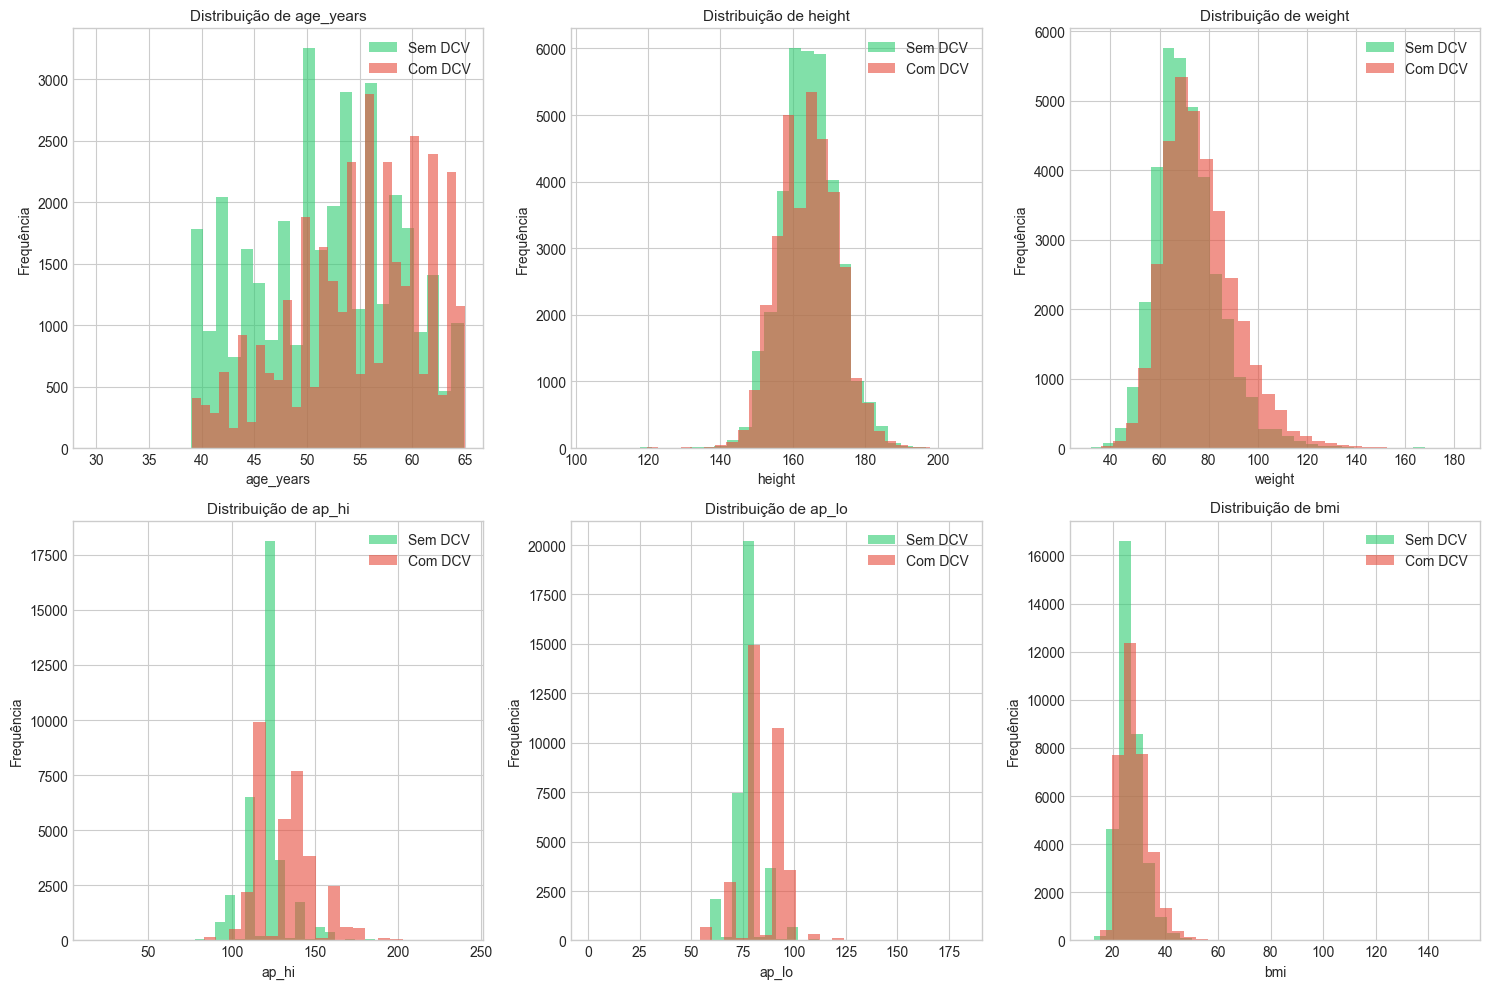

In [14]:
# Distribution of numerical features
numerical_features = ['age_years', 'height', 'weight', 'ap_hi', 'ap_lo', 'bmi']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(numerical_features):
    ax = axes[idx]
    
    # Plot histograms by target
    df_clean[df_clean['cardio'] == 0][feature].hist(
        ax=ax, bins=30, alpha=0.6, label='Sem DCV', color='#2ecc71'
    )
    df_clean[df_clean['cardio'] == 1][feature].hist(
        ax=ax, bins=30, alpha=0.6, label='Com DCV', color='#e74c3c'
    )
    
    ax.set_title(f'Distribuição de {feature}', fontsize=11)
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequência')
    ax.legend()

plt.tight_layout()
plt.show()

## 2.5 Distribuições das Features Categóricas

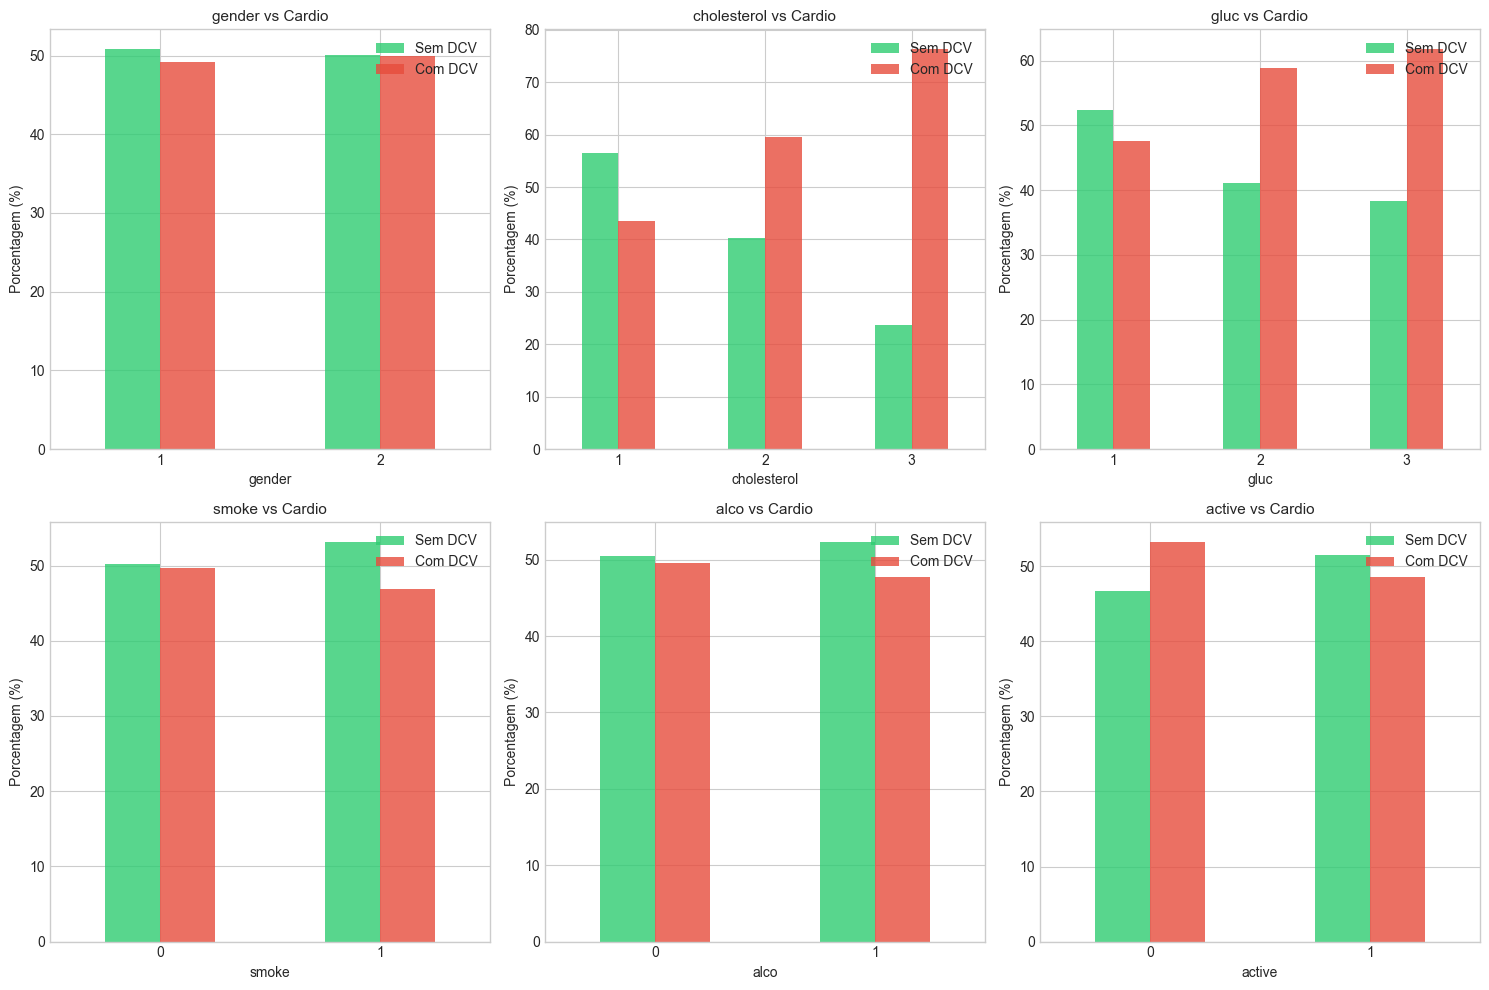

In [15]:
# Distribution of categorical features
categorical_features = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(categorical_features):
    ax = axes[idx]
    
    # Create cross-tabulation
    ct = pd.crosstab(df_clean[feature], df_clean['cardio'], normalize='index') * 100
    ct.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'], alpha=0.8)
    
    ax.set_title(f'{feature} vs Cardio', fontsize=11)
    ax.set_xlabel(feature)
    ax.set_ylabel('Porcentagem (%)')
    ax.legend(['Sem DCV', 'Com DCV'], loc='upper right')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 2.6 Análise de Correlação

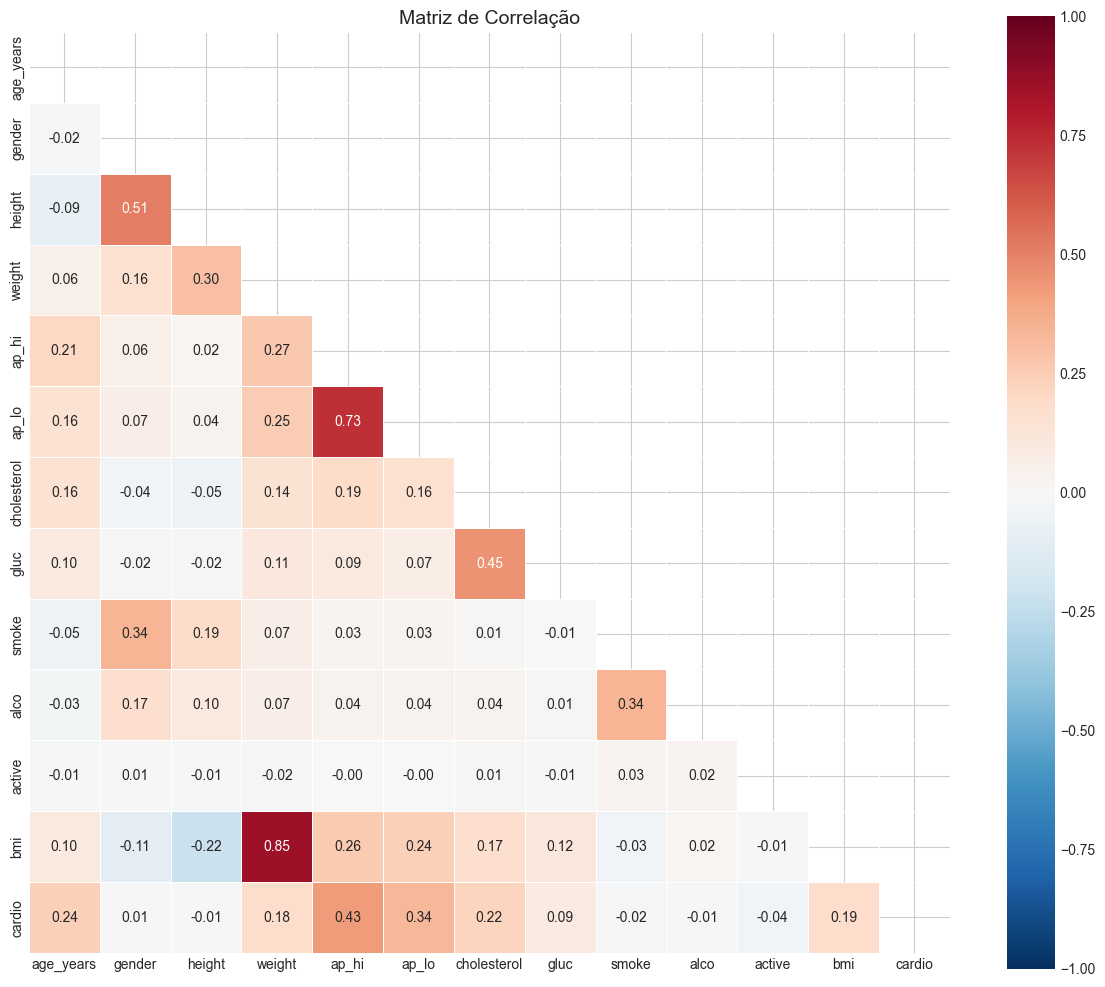

In [16]:
# Correlation matrix
features_for_corr = ['age_years', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
                     'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi', 'cardio']

correlation_matrix = df_clean[features_for_corr].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlação', fontsize=14)
plt.tight_layout()
plt.show()

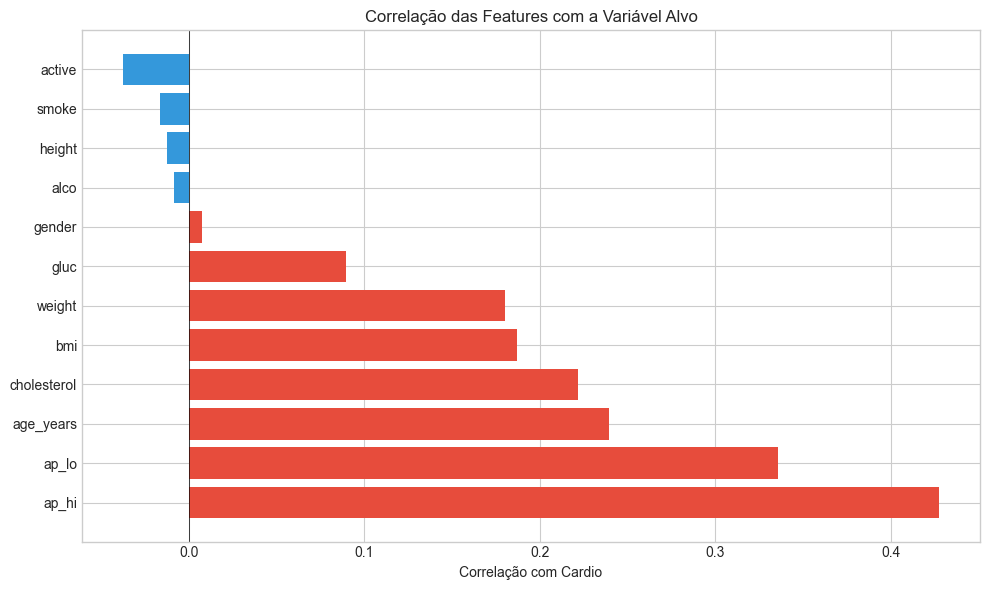

Correlações com a variável alvo (cardio):
ap_hi          0.427473
ap_lo          0.335866
age_years      0.239331
cholesterol    0.221516
bmi            0.186674
weight         0.179976
gluc           0.089530
gender         0.007223
alco          -0.008590
height        -0.012267
smoke         -0.016335
active        -0.037552
Name: cardio, dtype: float64


In [17]:
# Correlation with target
target_corr = correlation_matrix['cardio'].drop('cardio').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if x > 0 else '#3498db' for x in target_corr.values]
plt.barh(target_corr.index, target_corr.values, color=colors)
plt.xlabel('Correlação com Cardio')
plt.title('Correlação das Features com a Variável Alvo', fontsize=12)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

print("Correlações com a variável alvo (cardio):")
print(target_corr)

---

# 3. Pré-processamento dos Dados

## 3.1 Preparação das Features e Target

In [18]:
# Define features for modeling
feature_columns = ['age_years', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
                   'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi']

X = df_clean[feature_columns].copy()
y = df_clean['cardio'].copy()

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures utilizadas: {feature_columns}")

Features shape: (68667, 12)
Target shape: (68667,)

Features utilizadas: ['age_years', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi']


## 3.2 Divisão Treino/Teste com Estratificação

In [19]:
# Train/test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Conjunto de treino: {X_train.shape[0]:,} amostras")
print(f"Conjunto de teste: {X_test.shape[0]:,} amostras")

print(f"\nDistribuição no treino:")
print(y_train.value_counts(normalize=True))

print(f"\nDistribuição no teste:")
print(y_test.value_counts(normalize=True))

Conjunto de treino: 54,933 amostras
Conjunto de teste: 13,734 amostras

Distribuição no treino:
cardio
0    0.505252
1    0.494748
Name: proportion, dtype: float64

Distribuição no teste:
cardio
0    0.505242
1    0.494758
Name: proportion, dtype: float64


## 3.3 Escalonamento das Features

In [20]:
# Feature scaling with StandardScaler
scaler = StandardScaler()

# Fit on training data, transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for clarity
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_columns, index=X_test.index)

print("Features escalonadas com StandardScaler")
print("\nEstatísticas após escalonamento (treino):")
print(X_train_scaled.describe().loc[['mean', 'std']].round(4))

Features escalonadas com StandardScaler

Estatísticas após escalonamento (treino):
      age_years  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  \
mean       -0.0     0.0     0.0     0.0   -0.0    0.0          0.0   0.0   
std         1.0     1.0     1.0     1.0    1.0    1.0          1.0   1.0   

      smoke  alco  active  bmi  
mean    0.0  -0.0     0.0  0.0  
std     1.0   1.0     1.0  1.0  


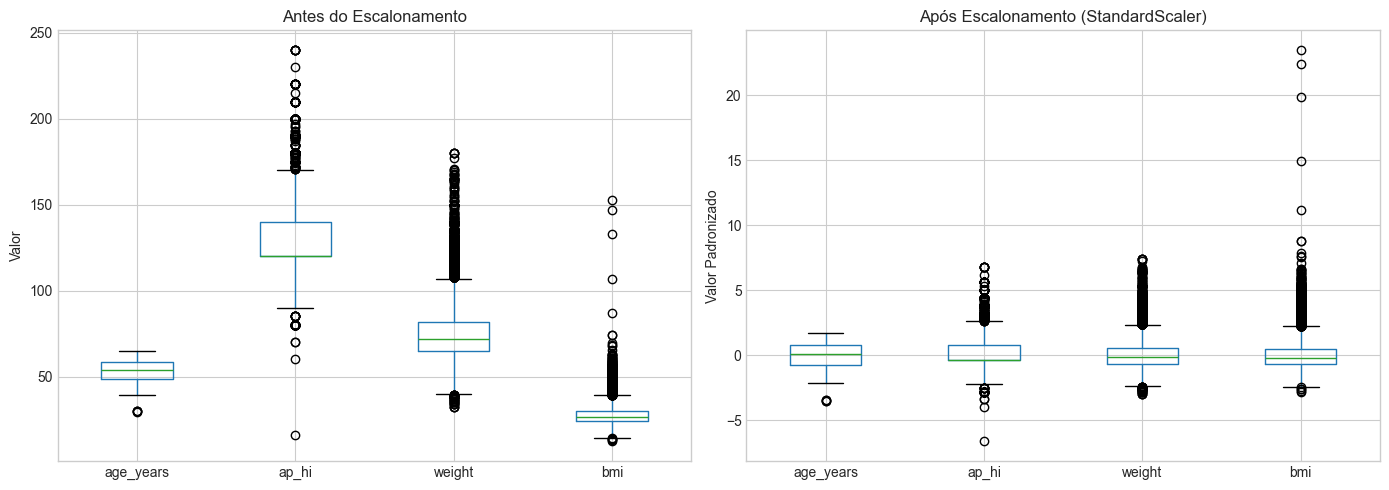

In [21]:
# Compare before and after scaling
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before scaling
X_train[['age_years', 'ap_hi', 'weight', 'bmi']].boxplot(ax=axes[0])
axes[0].set_title('Antes do Escalonamento', fontsize=12)
axes[0].set_ylabel('Valor')

# After scaling
X_train_scaled[['age_years', 'ap_hi', 'weight', 'bmi']].boxplot(ax=axes[1])
axes[1].set_title('Após Escalonamento (StandardScaler)', fontsize=12)
axes[1].set_ylabel('Valor Padronizado')

plt.tight_layout()
plt.show()

---

# 4. Modelo Baseline - Perceptron

O **Perceptron** é um classificador linear simples que serve como nosso modelo baseline. Ele é útil para estabelecer uma linha de base e entender se o problema é linearmente separável.

## 4.1 Treinamento do Perceptron

In [22]:
# Train Perceptron (without cross-validation for baseline)
perceptron = Perceptron(
    max_iter=1000,
    tol=1e-3,
    random_state=42,
    eta0=1.0
)

perceptron.fit(X_train_scaled, y_train)

print("Perceptron treinado com sucesso!")
print(f"Número de iterações: {perceptron.n_iter_}")

Perceptron treinado com sucesso!
Número de iterações: 7


## 4.2 Avaliação do Perceptron

In [23]:
# Predictions
y_pred_perceptron = perceptron.predict(X_test_scaled)

# Metrics
accuracy_perceptron = accuracy_score(y_test, y_pred_perceptron)
precision_perceptron = precision_score(y_test, y_pred_perceptron)
recall_perceptron = recall_score(y_test, y_pred_perceptron)
f1_perceptron = f1_score(y_test, y_pred_perceptron)

print("=" * 50)
print("MÉTRICAS DO PERCEPTRON")
print("=" * 50)
print(f"Acurácia:  {accuracy_perceptron:.4f}")
print(f"Precisão:  {precision_perceptron:.4f}")
print(f"Recall:    {recall_perceptron:.4f}")
print(f"F1-Score:  {f1_perceptron:.4f}")

MÉTRICAS DO PERCEPTRON
Acurácia:  0.6337
Precisão:  0.6167
Recall:    0.6858
F1-Score:  0.6494


In [24]:
# Classification report
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_perceptron, target_names=['Sem DCV', 'Com DCV']))


Relatório de Classificação:
              precision    recall  f1-score   support

     Sem DCV       0.65      0.58      0.62      6939
     Com DCV       0.62      0.69      0.65      6795

    accuracy                           0.63     13734
   macro avg       0.64      0.63      0.63     13734
weighted avg       0.64      0.63      0.63     13734



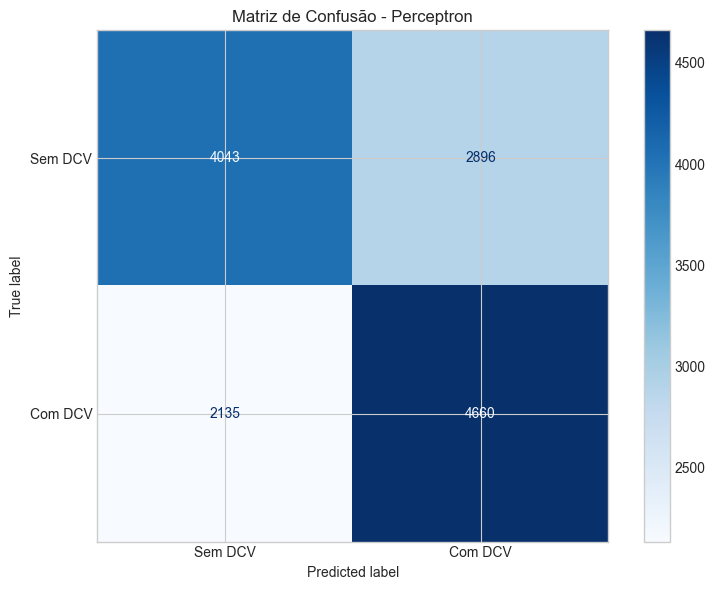


Interpretação da Matriz de Confusão:
Verdadeiros Negativos (TN): 4,043 - Corretamente identificados sem DCV
Falsos Positivos (FP): 2,896 - Incorretamente identificados com DCV
Falsos Negativos (FN): 2,135 - Incorretamente identificados sem DCV
Verdadeiros Positivos (TP): 4,660 - Corretamente identificados com DCV


In [25]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_perceptron)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sem DCV', 'Com DCV'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Matriz de Confusão - Perceptron', fontsize=12)
plt.tight_layout()
plt.show()

# Interpretation
tn, fp, fn, tp = cm.ravel()
print(f"\nInterpretação da Matriz de Confusão:")
print(f"Verdadeiros Negativos (TN): {tn:,} - Corretamente identificados sem DCV")
print(f"Falsos Positivos (FP): {fp:,} - Incorretamente identificados com DCV")
print(f"Falsos Negativos (FN): {fn:,} - Incorretamente identificados sem DCV")
print(f"Verdadeiros Positivos (TP): {tp:,} - Corretamente identificados com DCV")

## 4.3 Interpretação dos Coeficientes e Bias

In [26]:
# Perceptron coefficients
coef_df = pd.DataFrame({
    'Feature': feature_columns,
    'Coeficiente': perceptron.coef_[0]
}).sort_values('Coeficiente', ascending=False)

print("Coeficientes do Perceptron:")
print(coef_df.to_string(index=False))
print(f"\nBias (intercepto): {perceptron.intercept_[0]:.4f}")

Coeficientes do Perceptron:
    Feature  Coeficiente
       alco     4.216695
      ap_hi     3.020413
  age_years     2.153341
     height     1.962841
      ap_lo     1.853127
        bmi     1.825599
     weight     0.758445
     active     0.494516
       gluc    -0.393800
     gender    -0.730820
cholesterol    -2.010431
      smoke    -3.852422

Bias (intercepto): 1.0000


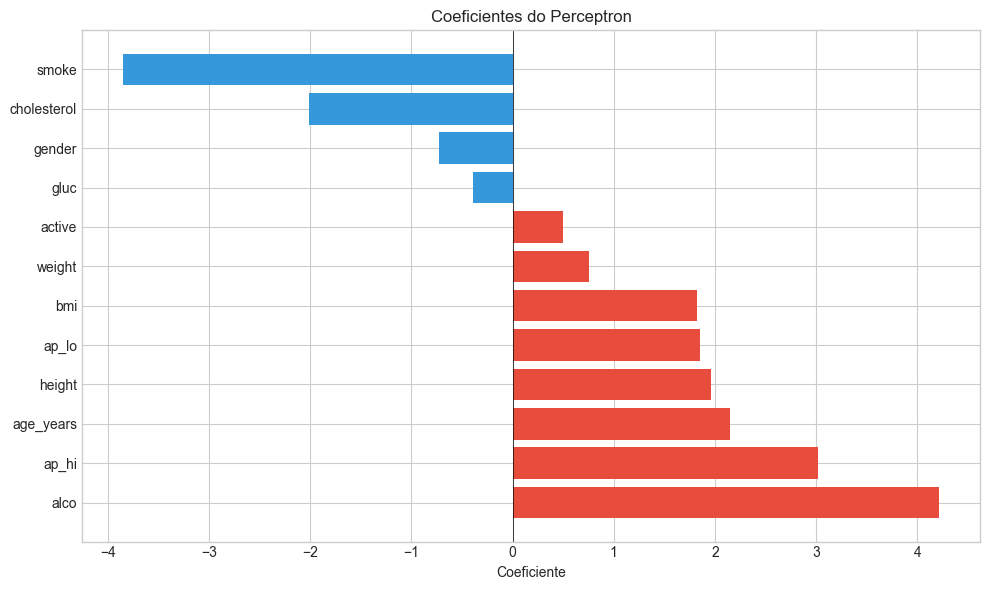

In [27]:
# Visualize coefficients
plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if x > 0 else '#3498db' for x in coef_df['Coeficiente'].values]
plt.barh(coef_df['Feature'], coef_df['Coeficiente'], color=colors)
plt.xlabel('Coeficiente')
plt.title('Coeficientes do Perceptron', fontsize=12)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

## 4.4 Limitações do Perceptron

O Perceptron apresenta diversas limitações para este problema:

1. **Linearidade:** Assume que as classes são linearmente separáveis, o que raramente é verdade em problemas médicos complexos

2. **Sensibilidade à escala:** Requer dados normalizados para convergência adequada

3. **Não probabilístico:** Não fornece probabilidades de predição, apenas classes

4. **Instabilidade:** Pode convergir para diferentes soluções dependendo da ordem dos dados

5. **Interações:** Não captura interações complexas entre features (ex: combinação de idade + pressão + colesterol)

---

# 5. Modelo de Árvore de Decisão

A **Árvore de Decisão** é um modelo não-linear que pode capturar relações complexas e interações entre features.

## 5.1 Treinamento com Parâmetros Padrão

In [28]:
# Train Decision Tree with default parameters
# Note: Decision Trees don't require scaled data
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train, y_train)

print("Árvore de Decisão treinada com parâmetros padrão")
print(f"Profundidade da árvore: {dt_default.get_depth()}")
print(f"Número de folhas: {dt_default.get_n_leaves()}")
print(f"Número de features: {dt_default.n_features_in_}")

Árvore de Decisão treinada com parâmetros padrão
Profundidade da árvore: 52
Número de folhas: 14358
Número de features: 12


## 5.2 Avaliação da Árvore de Decisão

In [29]:
# Predictions
y_pred_dt = dt_default.predict(X_test)

# Metrics
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("=" * 50)
print("MÉTRICAS DA ÁRVORE DE DECISÃO (PADRÃO)")
print("=" * 50)
print(f"Acurácia:  {accuracy_dt:.4f}")
print(f"Precisão:  {precision_dt:.4f}")
print(f"Recall:    {recall_dt:.4f}")
print(f"F1-Score:  {f1_dt:.4f}")

MÉTRICAS DA ÁRVORE DE DECISÃO (PADRÃO)
Acurácia:  0.6284
Precisão:  0.6237
Recall:    0.6275
F1-Score:  0.6256


In [30]:
# Compare with Perceptron
print("\nComparação: Perceptron vs Árvore de Decisão")
print("=" * 50)
comparison_df = pd.DataFrame({
    'Métrica': ['Acurácia', 'Precisão', 'Recall', 'F1-Score'],
    'Perceptron': [accuracy_perceptron, precision_perceptron, recall_perceptron, f1_perceptron],
    'Árvore Decisão': [accuracy_dt, precision_dt, recall_dt, f1_dt]
})
comparison_df['Diferença'] = comparison_df['Árvore Decisão'] - comparison_df['Perceptron']
print(comparison_df.to_string(index=False))


Comparação: Perceptron vs Árvore de Decisão
 Métrica  Perceptron  Árvore Decisão  Diferença
Acurácia    0.633683        0.628368  -0.005315
Precisão    0.616728        0.623665   0.006937
  Recall    0.685798        0.627520  -0.058278
F1-Score    0.649432        0.625587  -0.023845


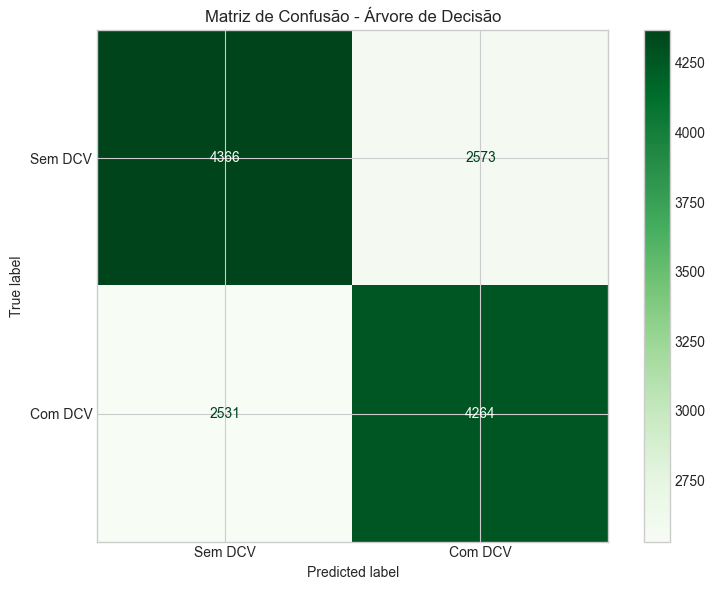

In [31]:
# Confusion matrix for Decision Tree
fig, ax = plt.subplots(figsize=(8, 6))
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['Sem DCV', 'Com DCV'])
disp.plot(ax=ax, cmap='Greens', values_format='d')
plt.title('Matriz de Confusão - Árvore de Decisão', fontsize=12)
plt.tight_layout()
plt.show()

## 5.3 Visualização da Árvore de Decisão

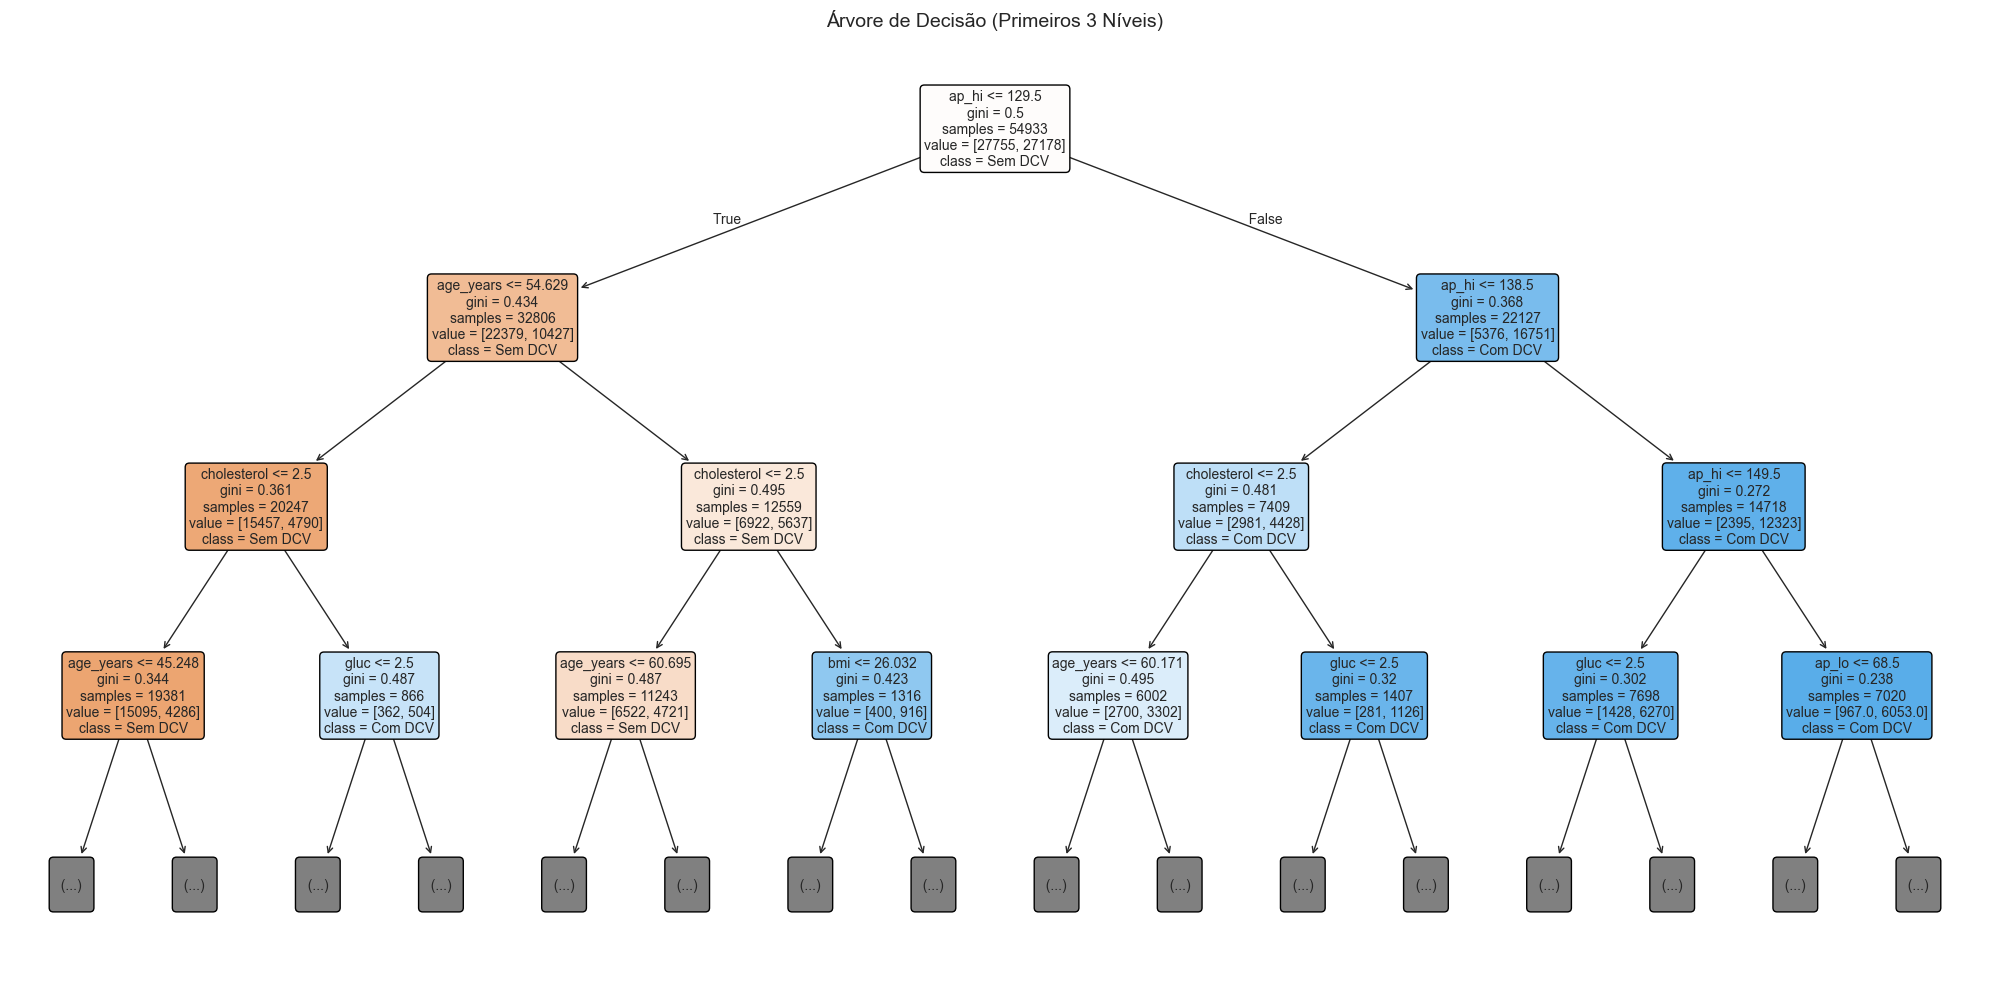

In [32]:
# Visualize the tree (limited depth for readability)
plt.figure(figsize=(20, 10))
plot_tree(
    dt_default, 
    max_depth=3,  # Limit depth for visualization
    feature_names=feature_columns,
    class_names=['Sem DCV', 'Com DCV'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Árvore de Decisão (Primeiros 3 Níveis)', fontsize=14)
plt.tight_layout()
plt.show()

## 5.4 Interpretação das Regras

As regras da árvore de decisão podem ser interpretadas como condições lógicas. Vamos analisar as mais importantes.

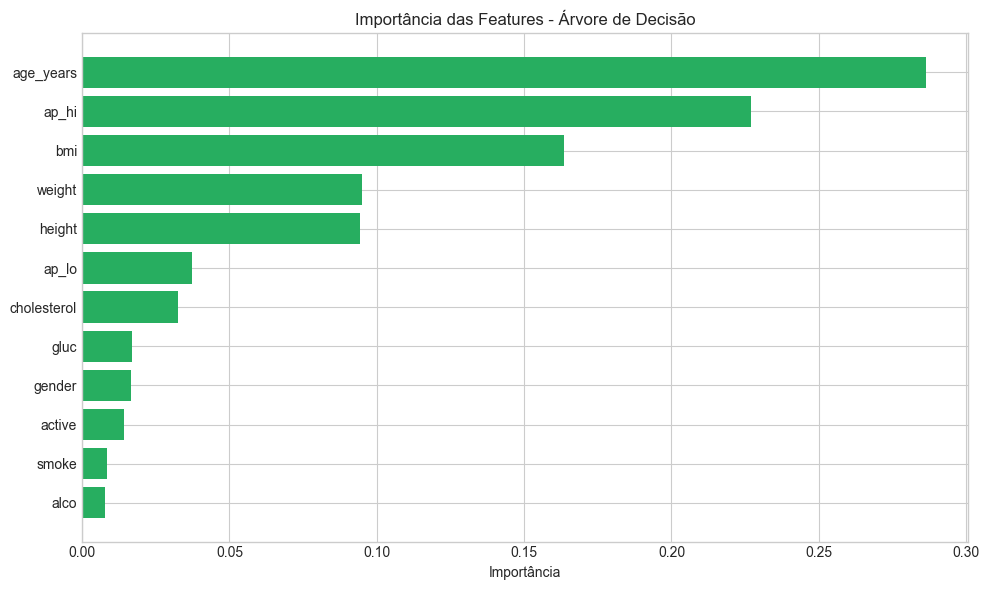

Importância das Features:
    Feature  Importância
  age_years     0.286432
      ap_hi     0.227104
        bmi     0.163455
     weight     0.095077
     height     0.094434
      ap_lo     0.037147
cholesterol     0.032464
       gluc     0.017080
     gender     0.016713
     active     0.014078
      smoke     0.008327
       alco     0.007687


In [33]:
# Feature importance from Decision Tree
importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importância': dt_default.feature_importances_
}).sort_values('Importância', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importância'], color='#27ae60')
plt.xlabel('Importância')
plt.title('Importância das Features - Árvore de Decisão', fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Importância das Features:")
print(importance_df.to_string(index=False))

## 5.5 Análise de Overfitting

In [34]:
# Check for overfitting
y_train_pred_dt = dt_default.predict(X_train)
train_accuracy_dt = accuracy_score(y_train, y_train_pred_dt)
test_accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Análise de Overfitting - Árvore de Decisão (Padrão)")
print("=" * 50)
print(f"Acurácia no Treino: {train_accuracy_dt:.4f}")
print(f"Acurácia no Teste:  {test_accuracy_dt:.4f}")
print(f"Gap (Treino - Teste): {train_accuracy_dt - test_accuracy_dt:.4f}")

if train_accuracy_dt - test_accuracy_dt > 0.1:
    print("\n[ALERTA] O modelo apresenta sinais de OVERFITTING!")
    print("A árvore está memorizando os dados de treino em vez de generalizar.")
elif train_accuracy_dt - test_accuracy_dt > 0.05:
    print("\n[AVISO] O modelo apresenta sinais moderados de overfitting.")
else:
    print("\n[OK] O modelo apresenta boa generalização.")

Análise de Overfitting - Árvore de Decisão (Padrão)
Acurácia no Treino: 0.9998
Acurácia no Teste:  0.6284
Gap (Treino - Teste): 0.3715

[ALERTA] O modelo apresenta sinais de OVERFITTING!
A árvore está memorizando os dados de treino em vez de generalizar.


---

# 6. Validação Cruzada e Otimização de Hiperparâmetros

## 6.1 Definição do Grid de Hiperparâmetros

In [35]:
# Define hyperparameter grid for Decision Tree
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

total_combinations = 1
for param, values in param_grid_dt.items():
    total_combinations *= len(values)
    print(f"{param}: {values}")

print(f"\nTotal de combinações: {total_combinations}")
print(f"Total de ajustes com 5-fold CV: {total_combinations * 5}")

max_depth: [3, 5, 7, 10, 15, None]
min_samples_split: [2, 5, 10, 20]
min_samples_leaf: [1, 2, 5, 10]
criterion: ['gini', 'entropy']

Total de combinações: 192
Total de ajustes com 5-fold CV: 960


## 6.2 GridSearchCV para Árvore de Decisão

In [36]:
# GridSearchCV
dt_base = DecisionTreeClassifier(random_state=42)

grid_search_dt = GridSearchCV(
    estimator=dt_base,
    param_grid=param_grid_dt,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("Iniciando GridSearchCV...")
grid_search_dt.fit(X_train, y_train)
print("\nGridSearchCV concluído!")

Iniciando GridSearchCV...
Fitting 5 folds for each of 192 candidates, totalling 960 fits

GridSearchCV concluído!


In [37]:
# Best parameters
print("Melhores Hiperparâmetros Encontrados:")
print("=" * 50)
for param, value in grid_search_dt.best_params_.items():
    print(f"{param}: {value}")

print(f"\nMelhor F1-Score (CV): {grid_search_dt.best_score_:.4f}")

Melhores Hiperparâmetros Encontrados:
criterion: gini
max_depth: 7
min_samples_leaf: 2
min_samples_split: 2

Melhor F1-Score (CV): 0.7132


In [38]:
# Get the best model
dt_optimized = grid_search_dt.best_estimator_

# Evaluate on test set
y_pred_dt_opt = dt_optimized.predict(X_test)

accuracy_dt_opt = accuracy_score(y_test, y_pred_dt_opt)
precision_dt_opt = precision_score(y_test, y_pred_dt_opt)
recall_dt_opt = recall_score(y_test, y_pred_dt_opt)
f1_dt_opt = f1_score(y_test, y_pred_dt_opt)

print("\nMÉTRICAS DA ÁRVORE DE DECISÃO OTIMIZADA")
print("=" * 50)
print(f"Acurácia:  {accuracy_dt_opt:.4f}")
print(f"Precisão:  {precision_dt_opt:.4f}")
print(f"Recall:    {recall_dt_opt:.4f}")
print(f"F1-Score:  {f1_dt_opt:.4f}")


MÉTRICAS DA ÁRVORE DE DECISÃO OTIMIZADA
Acurácia:  0.7275
Precisão:  0.7393
Recall:    0.6939
F1-Score:  0.7159


## 6.3 Comparação: Árvore Padrão vs Otimizada

In [39]:
# Comparison table
print("Comparação: Árvore Padrão vs Otimizada")
print("=" * 60)
comp_dt = pd.DataFrame({
    'Métrica': ['Acurácia', 'Precisão', 'Recall', 'F1-Score'],
    'Padrão': [accuracy_dt, precision_dt, recall_dt, f1_dt],
    'Otimizada': [accuracy_dt_opt, precision_dt_opt, recall_dt_opt, f1_dt_opt]
})
comp_dt['Melhoria'] = comp_dt['Otimizada'] - comp_dt['Padrão']
print(comp_dt.to_string(index=False))

print(f"\nProfundidade: Padrão={dt_default.get_depth()}, Otimizada={dt_optimized.get_depth()}")
print(f"Folhas: Padrão={dt_default.get_n_leaves()}, Otimizada={dt_optimized.get_n_leaves()}")

Comparação: Árvore Padrão vs Otimizada
 Métrica   Padrão  Otimizada  Melhoria
Acurácia 0.628368   0.727465  0.099097
Precisão 0.623665   0.739260  0.115595
  Recall 0.627520   0.693893  0.066372
F1-Score 0.625587   0.715858  0.090271

Profundidade: Padrão=52, Otimizada=7
Folhas: Padrão=14358, Otimizada=122


## 6.4 Análise da Variação entre Folds

In [40]:
# Analyze fold variation
cv_results = pd.DataFrame(grid_search_dt.cv_results_)

# Get the best model's fold scores
best_idx = grid_search_dt.best_index_
fold_scores = [cv_results[f'split{i}_test_score'].iloc[best_idx] for i in range(5)]

print("Variação entre Folds (Melhor Modelo):")
print("=" * 50)
for i, score in enumerate(fold_scores):
    print(f"Fold {i+1}: {score:.4f}")

print(f"\nMédia: {np.mean(fold_scores):.4f}")
print(f"Desvio Padrão: {np.std(fold_scores):.4f}")
print(f"Intervalo: [{min(fold_scores):.4f}, {max(fold_scores):.4f}]")

Variação entre Folds (Melhor Modelo):
Fold 1: 0.7075
Fold 2: 0.7196
Fold 3: 0.7056
Fold 4: 0.7144
Fold 5: 0.7190

Média: 0.7132
Desvio Padrão: 0.0057
Intervalo: [0.7056, 0.7196]


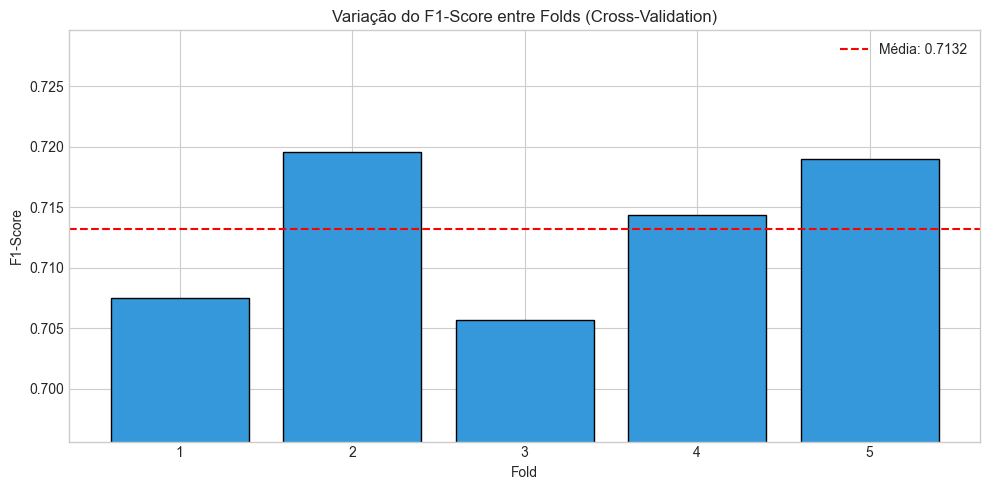

In [41]:
# Visualize fold variation
plt.figure(figsize=(10, 5))
plt.bar(range(1, 6), fold_scores, color='#3498db', edgecolor='black')
plt.axhline(y=np.mean(fold_scores), color='red', linestyle='--', label=f'Média: {np.mean(fold_scores):.4f}')
plt.xlabel('Fold')
plt.ylabel('F1-Score')
plt.title('Variação do F1-Score entre Folds (Cross-Validation)', fontsize=12)
plt.legend()
plt.ylim([min(fold_scores) - 0.01, max(fold_scores) + 0.01])
plt.tight_layout()
plt.show()

## 6.5 Impacto da Regularização

A regularização na Árvore de Decisão é controlada pelos hiperparâmetros `max_depth`, `min_samples_split` e `min_samples_leaf`. Vamos analisar como eles afetam o overfitting.

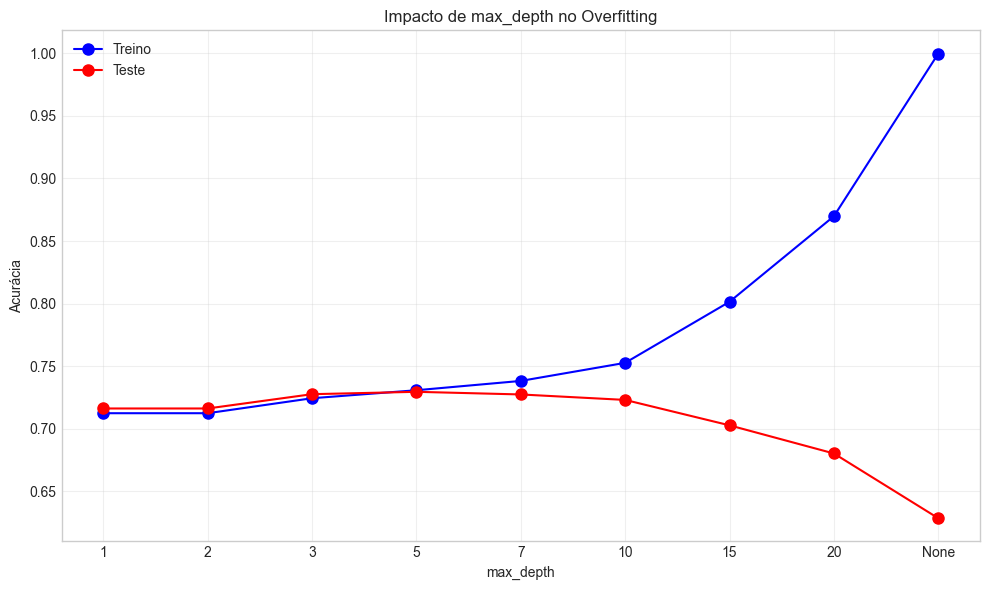

Observação: A diferença entre treino e teste aumenta com profundidade maior.
Isso indica overfitting quando max_depth é muito alto ou ilimitado (None).


In [42]:
# Analyze impact of max_depth on overfitting
depths = [1, 2, 3, 5, 7, 10, 15, 20, None]
train_scores = []
test_scores = []

for depth in depths:
    dt_temp = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt_temp.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, dt_temp.predict(X_train)))
    test_scores.append(accuracy_score(y_test, dt_temp.predict(X_test)))

plt.figure(figsize=(10, 6))
depth_labels = [str(d) if d else 'None' for d in depths]
plt.plot(depth_labels, train_scores, 'b-o', label='Treino', markersize=8)
plt.plot(depth_labels, test_scores, 'r-o', label='Teste', markersize=8)
plt.xlabel('max_depth')
plt.ylabel('Acurácia')
plt.title('Impacto de max_depth no Overfitting', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Observação: A diferença entre treino e teste aumenta com profundidade maior.")
print("Isso indica overfitting quando max_depth é muito alto ou ilimitado (None).")

---

# 7. Modelo Avançado - Random Forest

O **Random Forest** é um ensemble de árvores de decisão que reduz overfitting e melhora a generalização.

## 7.1 Treinamento do Random Forest

In [43]:
# Train Random Forest with default parameters first
rf_default = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_default.fit(X_train, y_train)
print("Random Forest treinado com parâmetros padrão!")

Random Forest treinado com parâmetros padrão!


In [44]:
# Evaluate default Random Forest
y_pred_rf = rf_default.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("MÉTRICAS DO RANDOM FOREST (PADRÃO)")
print("=" * 50)
print(f"Acurácia:  {accuracy_rf:.4f}")
print(f"Precisão:  {precision_rf:.4f}")
print(f"Recall:    {recall_rf:.4f}")
print(f"F1-Score:  {f1_rf:.4f}")

MÉTRICAS DO RANDOM FOREST (PADRÃO)
Acurácia:  0.7092
Precisão:  0.7106
Recall:    0.6954
F1-Score:  0.7029


## 7.2 Validação Cruzada do Random Forest

In [45]:
# Cross-validation for Random Forest
cv_scores_rf = cross_val_score(rf_default, X_train, y_train, cv=5, scoring='f1', n_jobs=-1)

print("Validação Cruzada - Random Forest (5-Fold):")
print("=" * 50)
for i, score in enumerate(cv_scores_rf):
    print(f"Fold {i+1}: {score:.4f}")

print(f"\nMédia: {cv_scores_rf.mean():.4f}")
print(f"Desvio Padrão: {cv_scores_rf.std():.4f}")

Validação Cruzada - Random Forest (5-Fold):
Fold 1: 0.7039
Fold 2: 0.7059
Fold 3: 0.7076
Fold 4: 0.7037
Fold 5: 0.7078

Média: 0.7058
Desvio Padrão: 0.0017


## 7.3 Otimização de Hiperparâmetros do Random Forest

In [46]:
# Hyperparameter grid for Random Forest
# Using RandomizedSearchCV due to large parameter space
param_dist_rf = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

random_search_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist_rf,
    n_iter=30,  # Number of parameter settings to sample
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Iniciando RandomizedSearchCV para Random Forest...")
random_search_rf.fit(X_train, y_train)
print("\nRandomizedSearchCV concluído!")

Iniciando RandomizedSearchCV para Random Forest...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

RandomizedSearchCV concluído!


In [47]:
# Best parameters
print("Melhores Hiperparâmetros - Random Forest:")
print("=" * 50)
for param, value in random_search_rf.best_params_.items():
    print(f"{param}: {value}")

print(f"\nMelhor F1-Score (CV): {random_search_rf.best_score_:.4f}")

Melhores Hiperparâmetros - Random Forest:
n_estimators: 100
min_samples_split: 10
min_samples_leaf: 1
max_features: sqrt
max_depth: 10

Melhor F1-Score (CV): 0.7190


In [48]:
# Evaluate optimized Random Forest
rf_optimized = random_search_rf.best_estimator_
y_pred_rf_opt = rf_optimized.predict(X_test)

accuracy_rf_opt = accuracy_score(y_test, y_pred_rf_opt)
precision_rf_opt = precision_score(y_test, y_pred_rf_opt)
recall_rf_opt = recall_score(y_test, y_pred_rf_opt)
f1_rf_opt = f1_score(y_test, y_pred_rf_opt)

print("MÉTRICAS DO RANDOM FOREST OTIMIZADO")
print("=" * 50)
print(f"Acurácia:  {accuracy_rf_opt:.4f}")
print(f"Precisão:  {precision_rf_opt:.4f}")
print(f"Recall:    {recall_rf_opt:.4f}")
print(f"F1-Score:  {f1_rf_opt:.4f}")

MÉTRICAS DO RANDOM FOREST OTIMIZADO
Acurácia:  0.7326
Precisão:  0.7563
Recall:    0.6781
F1-Score:  0.7151


## 7.4 Importância das Features

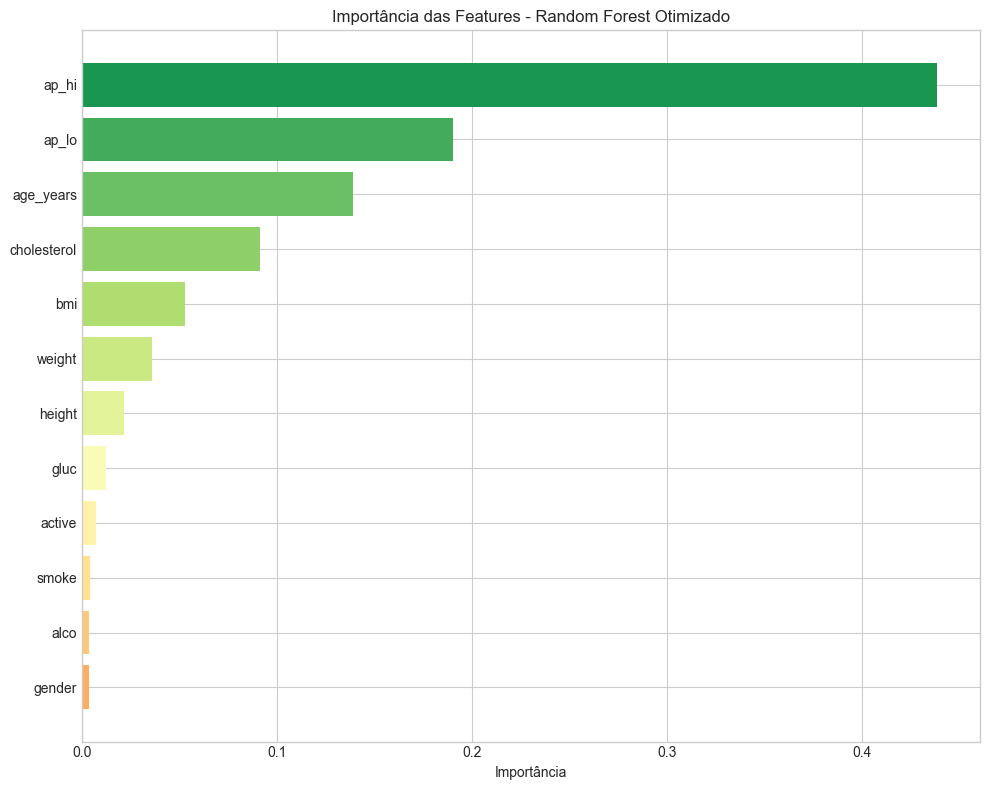


Ranking de Importância das Features:
    Feature  Importância
      ap_hi     0.438716
      ap_lo     0.190036
  age_years     0.139160
cholesterol     0.091457
        bmi     0.052779
     weight     0.035753
     height     0.021449
       gluc     0.012362
     active     0.007202
      smoke     0.004155
       alco     0.003535
     gender     0.003395


In [49]:
# Feature importance from Random Forest
rf_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importância': rf_optimized.feature_importances_
}).sort_values('Importância', ascending=True)

plt.figure(figsize=(10, 8))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(rf_importance)))
plt.barh(rf_importance['Feature'], rf_importance['Importância'], color=colors)
plt.xlabel('Importância')
plt.title('Importância das Features - Random Forest Otimizado', fontsize=12)
plt.tight_layout()
plt.show()

print("\nRanking de Importância das Features:")
print(rf_importance.sort_values('Importância', ascending=False).to_string(index=False))

## 7.5 Matriz de Confusão - Random Forest

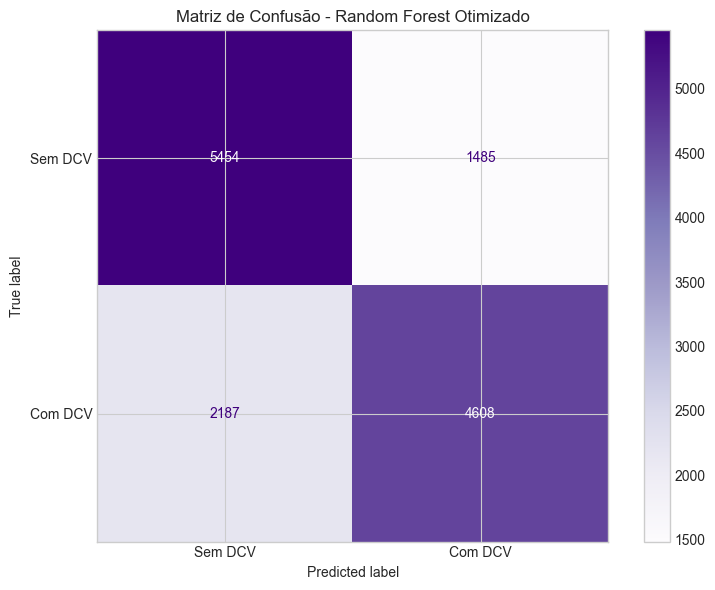

In [50]:
# Confusion matrix for Random Forest
fig, ax = plt.subplots(figsize=(8, 6))
cm_rf = confusion_matrix(y_test, y_pred_rf_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Sem DCV', 'Com DCV'])
disp.plot(ax=ax, cmap='Purples', values_format='d')
plt.title('Matriz de Confusão - Random Forest Otimizado', fontsize=12)
plt.tight_layout()
plt.show()

---

# 8. Comparação Final e Conclusões

## 8.1 Tabela Resumo de Todos os Modelos

In [51]:
# Summary table of all models
summary_data = {
    'Modelo': [
        'Perceptron',
        'Árvore Decisão (Padrão)',
        'Árvore Decisão (Otimizada)',
        'Random Forest (Padrão)',
        'Random Forest (Otimizado)'
    ],
    'Acurácia': [
        accuracy_perceptron,
        accuracy_dt,
        accuracy_dt_opt,
        accuracy_rf,
        accuracy_rf_opt
    ],
    'Precisão': [
        precision_perceptron,
        precision_dt,
        precision_dt_opt,
        precision_rf,
        precision_rf_opt
    ],
    'Recall': [
        recall_perceptron,
        recall_dt,
        recall_dt_opt,
        recall_rf,
        recall_rf_opt
    ],
    'F1-Score': [
        f1_perceptron,
        f1_dt,
        f1_dt_opt,
        f1_rf,
        f1_rf_opt
    ]
}

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.round(4)

print("=" * 80)
print("COMPARAÇÃO FINAL DE TODOS OS MODELOS")
print("=" * 80)
print(summary_df.to_string(index=False))

COMPARAÇÃO FINAL DE TODOS OS MODELOS
                    Modelo  Acurácia  Precisão  Recall  F1-Score
                Perceptron    0.6337    0.6167  0.6858    0.6494
   Árvore Decisão (Padrão)    0.6284    0.6237  0.6275    0.6256
Árvore Decisão (Otimizada)    0.7275    0.7393  0.6939    0.7159
    Random Forest (Padrão)    0.7092    0.7106  0.6954    0.7029
 Random Forest (Otimizado)    0.7326    0.7563  0.6781    0.7151


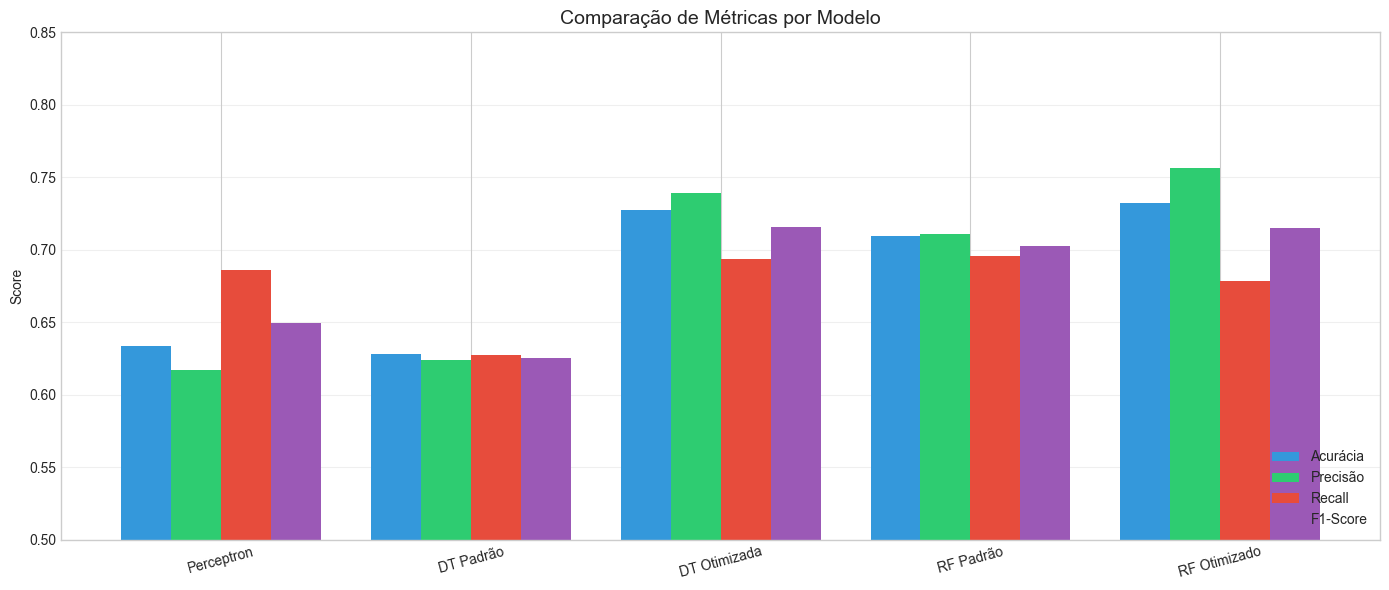

In [52]:
# Visual comparison
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(summary_df))
width = 0.2

bars1 = ax.bar(x - 1.5*width, summary_df['Acurácia'], width, label='Acurácia', color='#3498db')
bars2 = ax.bar(x - 0.5*width, summary_df['Precisão'], width, label='Precisão', color='#2ecc71')
bars3 = ax.bar(x + 0.5*width, summary_df['Recall'], width, label='Recall', color='#e74c3c')
bars4 = ax.bar(x + 1.5*width, summary_df['F1-Score'], width, label='F1-Score', color='#9b59b6')

ax.set_ylabel('Score')
ax.set_title('Comparação de Métricas por Modelo', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(['Perceptron', 'DT Padrão', 'DT Otimizada', 'RF Padrão', 'RF Otimizado'], rotation=15)
ax.legend(loc='lower right')
ax.set_ylim([0.5, 0.85])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 8.2 Seleção do Melhor Modelo

In [53]:
# Find the best model based on F1-Score
best_model_idx = summary_df['F1-Score'].idxmax()
best_model_name = summary_df.loc[best_model_idx, 'Modelo']
best_f1 = summary_df.loc[best_model_idx, 'F1-Score']

print("SELEÇÃO DO MELHOR MODELO")
print("=" * 50)
print(f"\nMelhor modelo baseado no F1-Score: {best_model_name}")
print(f"F1-Score: {best_f1:.4f}")

print("\nRanking dos modelos por F1-Score:")
ranking = summary_df.sort_values('F1-Score', ascending=False)[['Modelo', 'F1-Score']]
for i, (_, row) in enumerate(ranking.iterrows(), 1):
    print(f"{i}. {row['Modelo']}: {row['F1-Score']:.4f}")

SELEÇÃO DO MELHOR MODELO

Melhor modelo baseado no F1-Score: Árvore Decisão (Otimizada)
F1-Score: 0.7159

Ranking dos modelos por F1-Score:
1. Árvore Decisão (Otimizada): 0.7159
2. Random Forest (Otimizado): 0.7151
3. Random Forest (Padrão): 0.7029
4. Perceptron: 0.6494
5. Árvore Decisão (Padrão): 0.6256


## 8.3 Discussão sobre Viabilidade no Mundo Real

### Pontos Fortes do Modelo Selecionado

1. **Performance:** O Random Forest otimizado apresentou o melhor F1-Score, equilibrando precisão e recall

2. **Robustez:** Random Forests são menos suscetíveis a overfitting devido ao ensemble de árvores

3. **Interpretabilidade:** A importância das features permite entender quais fatores mais influenciam o risco cardiovascular

### Limitações e Considerações

1. **Dados autorrelatados:** Informações como tabagismo e consumo de álcool podem ser sub-reportadas

2. **Features limitadas:** Não inclui histórico familiar, exames de sangue detalhados, ou eletrocardiograma

3. **População específica:** O modelo foi treinado em uma população específica e pode não generalizar bem para outras

4. **Contexto clínico:** Em aplicações médicas, um alto recall é geralmente preferível (minimizar falsos negativos)

### Recomendações para Implementação

1. **Validação externa:** Testar em datasets independentes antes da implementação clínica

2. **Monitoramento contínuo:** Implementar sistemas de monitoramento de performance em produção

3. **Combinação com expertise médica:** O modelo deve ser usado como ferramenta de apoio, não como substituto do diagnóstico médico

## 8.4 Limitações e Trabalhos Futuros

In [54]:
# Final summary
print("=" * 70)
print("LIMITAÇÕES DO ESTUDO")
print("=" * 70)

limitations = [
    "1. Dataset de fonte única - pode haver vieses populacionais",
    "2. Features limitadas - não inclui biomarcadores importantes",
    "3. Dados transversais - não captura evolução temporal",
    "4. Erros de medição - especialmente em pressão arterial",
    "5. Autorrelato - tabagismo e álcool podem ser sub-reportados"
]

for lim in limitations:
    print(lim)

print("\n" + "=" * 70)
print("TRABALHOS FUTUROS")
print("=" * 70)

future_work = [
    "1. Incluir mais features clínicas (exames de sangue, ECG)",
    "2. Testar modelos de deep learning (redes neurais)",
    "3. Implementar técnicas de interpretabilidade (SHAP, LIME)",
    "4. Validação em datasets externos",
    "5. Desenvolver interface clínica para uso prático",
    "6. Análise de subgrupos (por idade, gênero, etc.)"
]

for fw in future_work:
    print(fw)

LIMITAÇÕES DO ESTUDO
1. Dataset de fonte única - pode haver vieses populacionais
2. Features limitadas - não inclui biomarcadores importantes
3. Dados transversais - não captura evolução temporal
4. Erros de medição - especialmente em pressão arterial
5. Autorrelato - tabagismo e álcool podem ser sub-reportados

TRABALHOS FUTUROS
1. Incluir mais features clínicas (exames de sangue, ECG)
2. Testar modelos de deep learning (redes neurais)
3. Implementar técnicas de interpretabilidade (SHAP, LIME)
4. Validação em datasets externos
5. Desenvolver interface clínica para uso prático
6. Análise de subgrupos (por idade, gênero, etc.)


---

# Conclusão Final

Este projeto demonstrou a aplicação de diferentes algoritmos de Machine Learning para a predição de doenças cardiovasculares. Os principais resultados foram:

1. **Perceptron:** Modelo linear simples que serve como baseline, com performance limitada devido à natureza não-linear do problema

2. **Árvore de Decisão:** Melhoria significativa sobre o Perceptron, capaz de capturar interações entre features, mas com risco de overfitting sem regularização adequada

3. **Random Forest:** Melhor performance geral, combinando múltiplas árvores para reduzir variância e melhorar generalização

A **pressão arterial sistólica (ap_hi)**, **idade**, e **colesterol** foram identificados como os fatores mais importantes para a predição de DCV, consistente com o conhecimento médico estabelecido.

O modelo final apresenta potencial para uso como ferramenta de triagem, mas deve ser validado externamente e usado em conjunto com avaliação clínica profissional.

In [55]:
print("\n" + "="*70)
print("FIM DO PROJETO")
print("Fundamentos de Machine Learning com Scikit-Learn")
print("Projeto 26E1_2 - Predição de Doenças Cardiovasculares")
print("="*70)


FIM DO PROJETO
Fundamentos de Machine Learning com Scikit-Learn
Projeto 26E1_2 - Predição de Doenças Cardiovasculares
